In [2]:
import pandas as pd
import scanpy as sc
from pathlib import Path

%config InlineBackend.figure_format = 'retina'
%matplotlib inline

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

DPI = 300 

sc.settings.set_figure_params(
    scanpy=True, dpi=100, transparent=True, vector_friendly=True, dpi_save=DPI)
from matplotlib import rcParams
rcParams["pdf.fonttype"] = 42

import warnings
warnings.filterwarnings('ignore')

sc.settings.verbosity = 0  

random_state = 7

sc.logging.print_header()

/var/folders/cy/ggjmyh4x3_j0fn2cqsk1f_800000gn/T/ipykernel_84301/1735800335.py:14: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(


Package,Version
pandas,2.3.3
scanpy,1.12
matplotlib,3.10.6
seaborn,0.13.2
Component,Info
Python,"3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:11:29) [Clang 20.1.8 ]"
OS,macOS-26.3.1-arm64-arm-64bit-Mach-O
CPU,"10 logical CPU cores, arm"
GPU,No GPU found
Updated,2026-04-08 14:57


In [3]:
adata1 = sc.read_h5ad("GSM2877127_SIGAB1.h5ad")
adata2 = sc.read_h5ad("GSM2877128_SIGAC1.h5ad")
adata3 = sc.read_h5ad("GSM2877129_SIGAD1.h5ad")
adata4 = sc.read_h5ad("GSM2877130_SIGAF1.h5ad")
adata5 = sc.read_h5ad("GSM2877131_SIGAG1.h5ad")
adata6 = sc.read_h5ad("GSM2877132_SIGAH1.h5ad")
adata7 = sc.read_h5ad("GSM2877133_SIGAG8.h5ad")
adata8 = sc.read_h5ad("GSM2877134_SIGAH8.h5ad")

adata = adata1.concatenate(adata2, adata3, adata4, adata5, adata6, adata7, adata8,
    batch_key="sample",join="inner")

del adata1, adata2, adata3, adata4, adata5, adata6, adata7, adata8

adata

adata.var.describe()

,n_cells_by_counts-0,mean_counts-0,pct_dropout_by_counts-0,total_counts-0,n_cells_by_counts-1,mean_counts-1,pct_dropout_by_counts-1,total_counts-1,n_cells_by_counts-2,mean_counts-2,...,pct_dropout_by_counts-5,total_counts-5,n_cells_by_counts-6,mean_counts-6,pct_dropout_by_counts-6,total_counts-6,n_cells_by_counts-7,mean_counts-7,pct_dropout_by_counts-7,total_counts-7
count,27019.000000,27019.000000,27019.000000,27019.000000,27019.000000,27019.000000,27019.000000,27019.000000,27019.000000,27019.000000,...,27019.000000,27019.000000,27019.000000,27019.000000,27019.000000,2.701900e+04,27019.000000,27019.000000,27019.000000,2.701900e+04
mean,867.548133,0.297526,89.705137,2507.247803,769.048336,0.299352,89.653594,2225.080078,713.411747,0.265723,...,88.716503,3005.093018,967.359858,0.647711,87.683221,5.087119e+03,868.805026,0.683115,87.262791,4.659529e+03
std,1632.099648,2.098689,19.367505,17686.316406,1443.651484,2.103361,19.422191,15634.505859,1379.061913,1.897443,...,20.840359,20470.179688,1811.156442,5.235445,23.060306,4.111630e+04,1599.633204,5.411338,23.451594,3.691114e+04
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00
25%,0.000000,0.000000,87.807049,0.000000,0.000000,0.000000,87.663124,0.000000,0.000000,0.000000,...,86.500066,0.000000,0.000000,0.000000,86.592819,0.000000e+00,0.000000,0.000000,85.588623,0.000000e+00
50%,12.000000,0.001424,99.857601,12.000000,10.000000,0.001480,99.865465,11.000000,10.000000,0.001336,...,99.881000,10.000000,9.000000,0.001146,99.885409,9.000000e+00,9.000000,0.001319,99.868055,9.000000e+00
75%,1027.500000,0.135576,100.000000,1142.500000,917.000000,0.137091,100.000000,1019.000000,814.000000,0.119490,...,100.000000,1160.000000,1053.000000,0.151897,100.000000,1.193000e+03,983.000000,0.165152,100.000000,1.126500e+03
max,8427.000000,112.477036,100.000000,947844.000000,7433.000000,113.747208,100.000000,845483.000000,7486.000000,102.812050,...,100.000000,683312.000000,7854.000000,145.532211,100.000000,1.143010e+06,6821.000000,150.385132,100.000000,1.025777e+06


1) Preprocess the data , perform dimensionality reduction and clustering

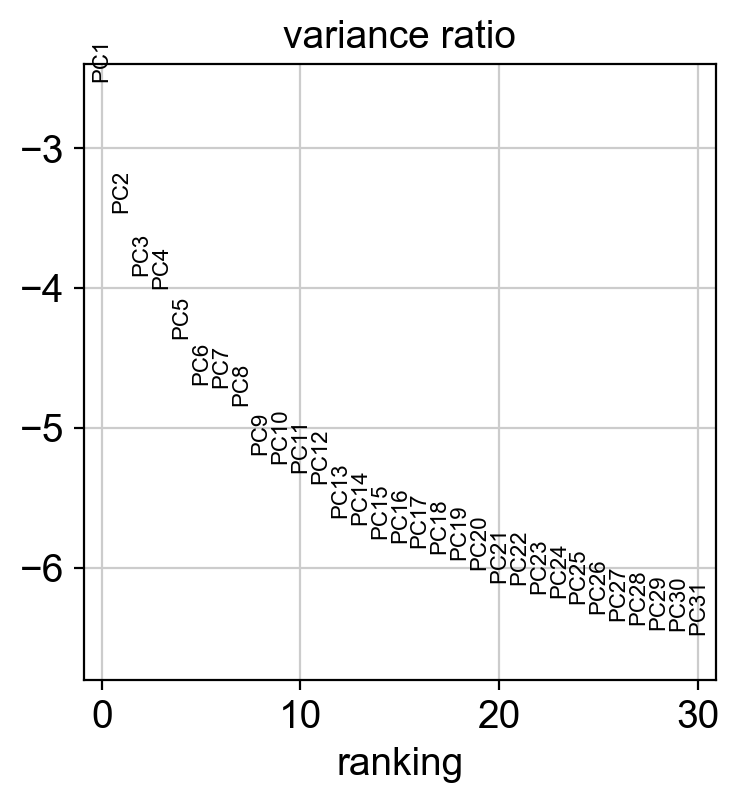

In [4]:
# preprocessing
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000, subset=True)
sc.pp.scale(adata, max_value=10)

# PCA
sc.tl.pca(adata, svd_solver='arpack', random_state=random_state)
sc.pl.pca_variance_ratio(adata, log=True)


In [ ]:
# Neighbors + Clustering
!pip install leidenalg
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
sc.tl.leiden(adata, resolution=0.5, key_added="leiden")

# UMAP
sc.tl.umap(adata)
sc.pl.umap(adata, color="leiden")

2) Perform a differential expression analysis, what are the top 5 differentially expressed genes per cluster? 

In [1]:
# Differential expression
sc.tl.rank_genes_groups(adata, groupby="leiden",use_raw=True,layer=None,pts=True, method="wilcoxon")
sc.pl.rank_genes_groups(adata, n_genes=5, sharey=False)
import pandas as pd

result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names

top5_genes = pd.DataFrame({group: result['names'][group][:5] for group in groups})
top5_genes

# mt-Co1, Malat1, Pim1, Sox4, Hlf are the top 5 differentially expressed genes per cluster.	

NameError: name 'sc' is not defined

3) Produce a UMAP with cells coloured by their clusters and another coloured by the cell type.

In [ ]:
import itertools

markers2plot = list(itertools.chain(*list(markers.values())))  
sc.pl.umap(adata, use_raw=True, color=["leiden", "Cd34", "Gata1", "Mpo", "Cd3e"],show=True)

## The kernel repeatedly crashed during execution, so I was unable to annotate properly.
new_cluster_annotation = {
    "0": "HSC",
    "1": "Myeloid",
    "2": "Erythroid",
    "3": "Lymphoid",
}
adata.obs["cell_type"] = adata.obs["leiden"].map(new_cluster_annotation).astype("category")

sc.pl.umap(adata, color=["leiden"],show=True)
sc.pl.umap(adata, color=["cell_type"],show=True)

## The kernel repeatedly crashed during execution, so I was unable to obtain the results.

4)	Perform DTP trajectory analysis. 
    Produce a UMAP coloured by the DTP trajectory pseudotime. 
    How many lineages are there? 

In [ ]:
!pip install leidenalg
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
sc.tl.diffmap(adata)

# diffusion component 
sc.pl.scatter(
    adata, basis="diffmap", color="leiden", components=["1,2"],
    frameon=True, title="Diffusion components 1 and 2")

sc.pl.scatter(
    adata, basis="diffmap", color="leiden", components=["2,3"],
    frameon=True, title="Diffusion components 2 and 3")

sc.tl.paga(adata, groups="leiden")
sc.pl.paga(adata)
sc.tl.umap(adata, init_pos="paga")

root_cluster = "0"   
root_cell = adata.obs[adata.obs["leiden"] == root_cluster].index[0]
adata.uns["iroot"] = adata.obs.index.get_loc(root_cell)

sc.tl.dpt(adata)
sc.pl.umap(
    adata,
    color=["dpt_pseudotime", "leiden"],
    color_map="plasma_r",
    ncols=2,
    show=True)

## The kernel repeatedly crashed during execution, so I was unable to obtain the results.

5)	Are there any limitations of this experiment? Would you make any changes to this analysis? Can you think of next steps for this analysis?

This analysis has several limitations. The data represents a static snapshot rather than a true time series, so pseudotime is inferred and may not fully capture the actual dynamics. In addition, single-cell RNA-seq data is prone to dropout events, which can introduce noise and missing values in gene expression.

To improve the analysis, batch correction methods such as Harmony could be applied to reduce sample-specific effects. It would also be useful to compare results with alternative trajectory inference methods like Slingshot, to check the robustness of the inferred lineage. Increasing the clustering resolution might further reveal smaller subpopulations that are currently not captured.

For the next work, lineage-specific differential expression analysis could help identify key regulators of differentiation. Gene regulatory network inference may provide additional insight into transcriptional control. RNA velocity analysis could also be considered to better understand the directionality of cell state transitions. Integrating multi-omics data would likely give a more comprehensive view of hematopoiesis.